In [ ]:
#Middleware.

"""
Middleware provides a way to more tightly control what happend inside the agent.
Middleware is useful for the following:

> Tracking agent behaviour with logging, analytics, and debugging.
> Transforming prompts, tool selection, and output formatting.
> Adding retries , fallbacks, and early termination logic.
> Applying rate limits, guardrails, and PII detection.
"""

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [ ]:
#AIRPORT Security.

"""
Passenger -> security check -> Immigration -> Board -> Flight

Security -> laggage check
Immigration -> Passport check
Board -> Boarding Pass 

Built in middle wares.

Summarization -> agent 
Human in the feedback
Model call limits
Tool call limit
To do list.

That summarization will attech to the agent its provieds an output.



"""

In [ ]:
##Summarization middle ware.
"""
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context.

Summarization is useful for the following.

> Long running conversations that exceed context window.
> Multi-turn dialouges with extensive library.
> Applications where preserving full conversations context matters.
"""


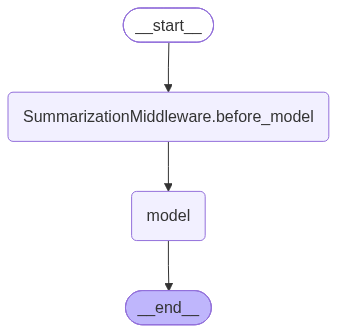

In [7]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver

model = init_chat_model("groq:llama-3.3-70b-versatile")

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("messages", 10),
            keep=("messages", 4),
        )
    ],
)
agent

In [8]:
#Run with tread id.
config = {"configurable":{"thread_id":"test-1"}}

In [11]:
from langchain_core.messages import HumanMessage

config = {
    "configurable": {
        "thread_id": "demo"
    }
}

questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response = agent.invoke(
        {"messages": [HumanMessage(content=q)]},
        config=config
    )

    print("Question:", q)
    print("Answer:", response["messages"][-1].content)
    print("-" * 50)

Question: What is 2+2?
Answer: The answer is 4.
--------------------------------------------------
Question: What is 10*5?
Answer: The answer is 50.
--------------------------------------------------
Question: What is 100/4?
Answer: The answer is 25.
--------------------------------------------------
Question: What is 15-7?
Answer: The answer is 8.
--------------------------------------------------
Question: What is 3*3?
Answer: The answer is 9.
--------------------------------------------------
Question: What is 4*4?
Answer: The answer is 16.
--------------------------------------------------


In [12]:

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

model = init_chat_model("groq:llama-3.3-70b-versatile")


@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long responses to use more tokens."""
    return f"""
Hotels in {city}:

1. Grand Hotel - 5 star, $350/night, spa, pool, gym
2. City Inn - 4 star, $180/night, business center
3. Budget Stay - 3 star, $75/night, free WiFi
"""


agent = create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("tokens", 550),
            keep=("tokens", 200),
        )
    ],
)

config = {
    "configurable": {
        "thread_id": "test-1"
    }
}

config = {"configurable":{"thread_id":"test-1"}}

#Token counter (approximate)

def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars//4 # 4 chars = 1 token

In [15]:
#Run test.

cities = {"paris", "London", "Tokyo", "New York", "Dubai", "Singapore"}

for city in cities:
    response = agent.invoke(
        {
            "messages":[HumanMessage(content=f"Find hotels in {city}")]
        },
        config = config
    )

    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens}, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

London: ~267, 6 messages
[HumanMessage(content="Here is a summary of the conversation to date:\n\n## SESSION INTENT\nThe user's primary goal is to find hotels in London.\n\n## SUMMARY\nThe user requested a search for hotels in London, and the search results were provided, yielding a list of hotels: \n1. Grand Hotel - 5 star, $350/night, spa, pool, gym\n2. City Inn - 4 star, $180/night, business center\n3. Budget Stay - 3 star, $75/night, free WiFi\n\n## ARTIFACTS\nNone\n\n## NEXT STEPS\nThe next steps would be for the user to select a hotel from the provided list or to refine their search criteria to find more suitable options.", additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='8d49a6e4-2563-48c9-ab74-1d9822f6b633'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6ce028fwr', 'function': {'arguments': '{"city":"London"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens

In [19]:
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware

from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

# Initialize model
model = init_chat_model(
    "groq:llama-3.3-70b-versatile"
)

# Tool
@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email."""
    return f"Email sent to {to} with subject '{subject}'."

# Create Agent
agent = create_agent(
    model=model,
    tools=[send_email],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email": True
            }
        )
    ],
    checkpointer=InMemorySaver(),
)

config = {
    "configurable": {
        "thread_id": "thread-1"
    }
}

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Send an email to john@example.com with subject 'Meeting' and body 'Meeting at 5 PM today.'"
            }
        ]
    },
    config=config,
)

print(result)




{'messages': [HumanMessage(content="Send an email to john@example.com with subject 'Meeting' and body 'Meeting at 5 PM today.'", additional_kwargs={}, response_metadata={}, id='78cfe59f-fb1a-48f0-95cc-11378c2ccd03'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'fc624t5hm', 'function': {'arguments': '{"body":"Meeting at 5 PM today.","subject":"Meeting","to":"john@example.com"}', 'name': 'send_email'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 244, 'total_tokens': 278, 'completion_time': 0.085999821, 'completion_tokens_details': None, 'prompt_time': 0.016474694, 'prompt_tokens_details': None, 'queue_time': 0.161940333, 'total_time': 0.102474515}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fb950-32a4-7b91-8c4a-7504cfac7f01-0', tool_calls=[{'name': 'send_email